In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("hr_prediction.xlsx")
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,2019-03-01,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2016-01-02,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2019-02-28,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,2015-02-09,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2019-02-21,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2019-01-02,0,11


In [4]:
print("=========================== Detail========================\n")
print(f"Shape of the dataset: {df.shape[0]} (rows) X {df.shape[1]} (columns)")
print(f"Duplicate entries: {df.duplicated().sum()}")
print(f"Dimensions: {df.ndim} D \n")
print("============Missing values=======================\n ")

print(f"Total Null Values: {df.isnull().sum().sum()}\n")
print("Null values per column:")

    
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

# Print results
for col, count in null_counts.items():
    print(f"{col}: {count}")
print("=" * 60)


=========================== Detail========================

Shape of the dataset: 311 (rows) X 36 (columns)
Duplicate entries: 0
Dimensions: 2 D 

============Missing values=======================
 
Total Null Values: 215

Null values per column:
DateofTermination: 207
ManagerID: 8


In [5]:
df=df.drop(columns=['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID','Zip','PositionID','State','CitizenDesc', 'HispanicLatino', 'RaceDesc','TermReason'])

In [6]:
df.columns.unique()

Index(['FromDiversityJobFairID', 'Salary', 'Termd', 'Position', 'DOB', 'Sex',
       'MaritalDesc', 'DateofHire', 'DateofTermination', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='str')

In [7]:
# Calculate Age at the time of the review
df['Age_At_Review'] = ((df['LastPerformanceReview_Date'] - df['DOB']).dt.days // 365.25).astype(int)
df["Tenure"]=((df['LastPerformanceReview_Date'] - df['DateofHire']).dt.days // 365.25).astype(int)



In [8]:
df=df.drop(columns=['DOB', 'LastPerformanceReview_Date', 'RecruitmentSource','FromDiversityJobFairID'])
df

,Salary,Termd,Position,Sex,MaritalDesc,DateofHire,DateofTermination,EmploymentStatus,Department,ManagerName,ManagerID,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,Age_At_Review,Tenure
0,62506,0,Production Technician I,M,Single,2011-05-07,NaT,Active,Production,Michael Albert,22.0,Exceeds,4.60,5,0,0,1,35,7
1,104437,1,Sr. DBA,M,Married,2015-03-30,2016-06-16,Voluntarily Terminated,IT/IS,Simon Roup,4.0,Fully Meets,4.96,3,6,0,17,40,0
2,64955,1,Production Technician II,F,Married,2011-05-07,2012-09-24,Voluntarily Terminated,Production,Kissy Sullivan,20.0,Fully Meets,3.02,3,0,0,3,23,1
3,64991,0,Production Technician I,F,Married,2008-07-01,NaT,Active,Production,Elijiah Gray,16.0,Fully Meets,4.84,5,0,0,15,30,10
4,50825,1,Production Technician I,F,Divorced,2011-11-07,2016-06-09,Voluntarily Terminated,Production,Webster Butler,39.0,Fully Meets,5.00,4,0,0,2,26,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,65893,0,Production Technician II,M,Single,2014-07-07,NaT,Active,Production,Kissy Sullivan,20.0,Fully Meets,4.07,4,0,0,13,33,4
307,48513,1,Production Technician I,F,Single,2008-02-09,2015-09-29,Voluntarily Terminated,Production,Brannon Miller,12.0,PIP,3.20,2,0,5,4,32,7
308,220450,0,CIO,F,Single,2010-10-04,NaT,Active,IT/IS,Janet King,2.0,Exceeds,4.60,5,6,0,16,39,8
309,89292,0,Data Analyst,F,Single,2015-03-30,NaT,Active,IT/IS,Simon Roup,4.0,Fully Meets,5.00,3,5,0,11,39,3


C:\Users\user'\AppData\Local\Temp\ipykernel_14772\3697678879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Termd', palette='viridis')


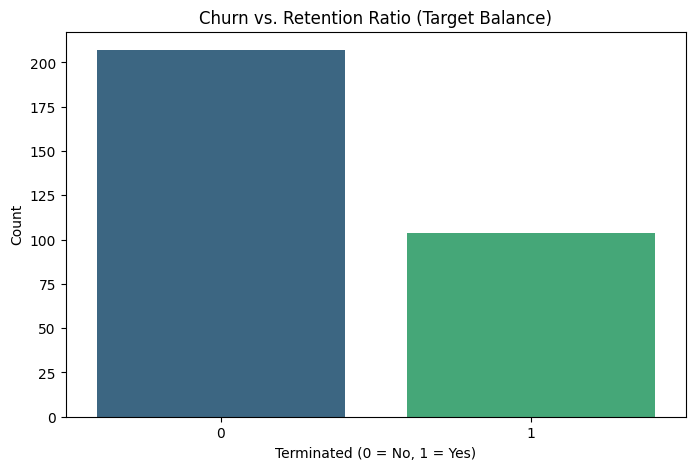

In [9]:
# Count Plot of 'Termd' to visualize the churn vs. retention ratio
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Termd', palette='viridis')
plt.title('Churn vs. Retention Ratio (Target Balance)')
plt.xlabel('Terminated (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0, 0.5, 'DaysLateLast30'),
  Text(0, 1.5, 'Absences'),
  Text(0, 2.5, 'EmpSatisfaction'),
  Text(0, 3.5, 'EngagementSurvey'),
  Text(0, 4.5, 'Salary'),
  Text(0, 5.5, 'Age_At_Review'),
  Text(0, 6.5, 'SpecialProjectsCount'),
  Text(0, 7.5, 'Tenure')])

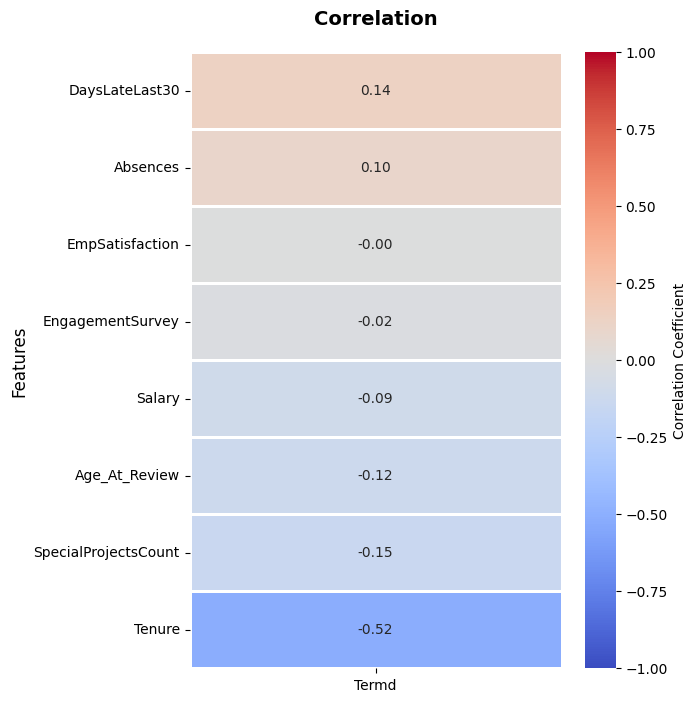

In [10]:
# 1. Define your numerical features and the target
# We only use numerical or ordinal data for correlation math
features = [
    'Termd', 'Salary', 'EngagementSurvey', 'EmpSatisfaction', 
    'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 
    'Age_At_Review', 'Tenure'
]

# 2. Filter the dataframe to only include these columns and drop any leftover NaNs
df_corr = df[features].dropna()

# 3. Calculate the correlation matrix (Pearson by default)
corr_matrix = df_corr.corr()

# 4. Isolate the 'Termd' column, drop the self-correlation (Termd vs Termd is always 1.0), 
# and sort the values so the strongest drivers are at the top and bottom.
target_corr = corr_matrix[['Termd']].drop('Termd').sort_values(by='Termd', ascending=False)

# 5. Plotting the Heatmap
plt.figure(figsize=(6, 8)) # Tall and narrow looks best for a 1D heatmap
sns.heatmap(
    target_corr, 
    annot=True,               # Show the actual correlation numbers
    cmap='coolwarm',          # Blue = Negative correlation, Red = Positive correlation
    vmin=-1, vmax=1,          # Lock the scale from -1 to 1
    fmt=".2f",                # Round to 2 decimal places
    linewidths=2,             # Add space between the blocks for readability
    cbar_kws={'label': 'Correlation Coefficient'}
)

# 6. Professional Styling
plt.title("Correlation", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Features", fontsize=12)
plt.yticks(rotation=0) # Keep labels horizontal

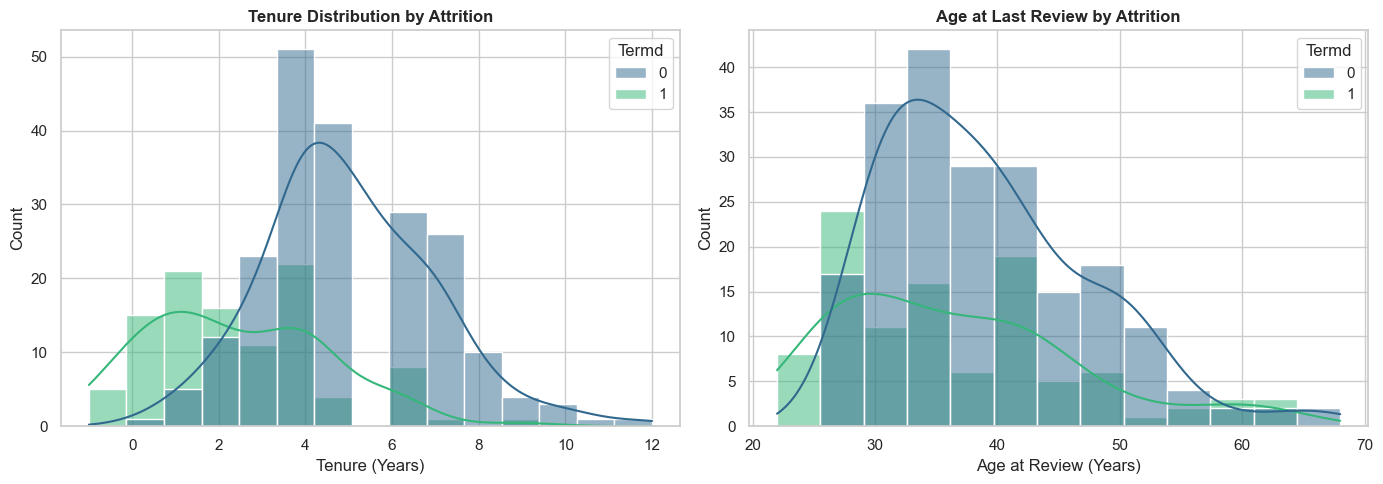

In [11]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure Plot
sns.histplot(data=df, x='Tenure', hue='Termd', kde=True, palette='viridis', ax=axes[0])
axes[0].set_title('Tenure Distribution by Attrition', fontweight='bold')
axes[0].set_xlabel('Tenure (Years)')

# Age At Review Plot
sns.histplot(data=df, x='Age_At_Review', hue='Termd', kde=True, palette='viridis', ax=axes[1])
axes[1].set_title('Age at Last Review by Attrition', fontweight='bold')
axes[1].set_xlabel('Age at Review (Years)')

plt.tight_layout()
plt.show()

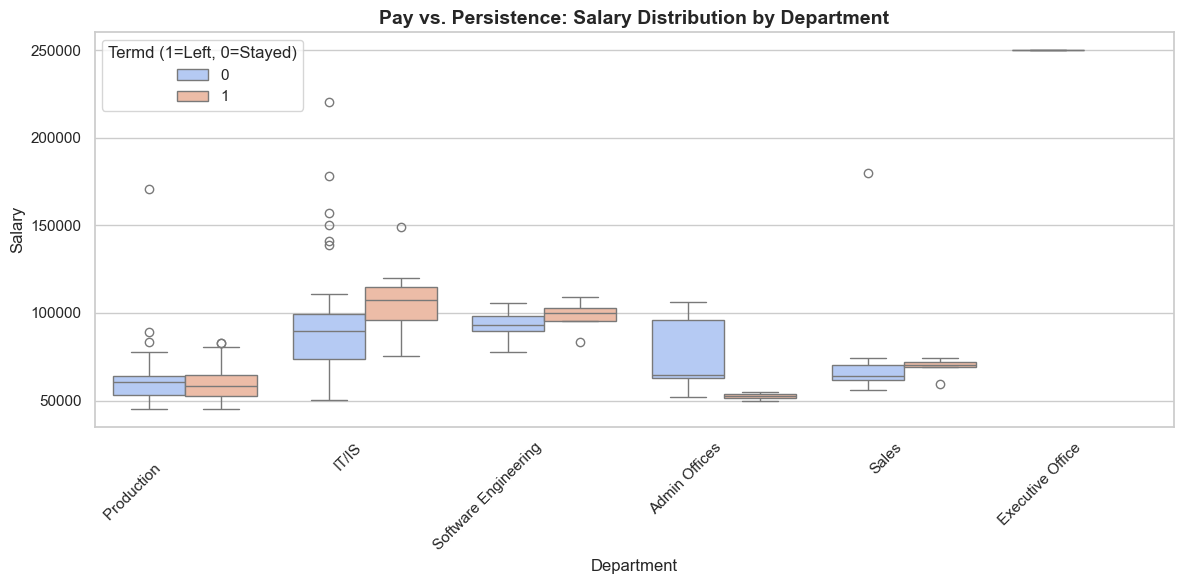

In [12]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='Department', y='Salary', hue='Termd', palette='coolwarm')

plt.title('Pay vs. Persistence: Salary Distribution by Department', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Termd (1=Left, 0=Stayed)', loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\user'\AppData\Local\Temp\ipykernel_14772\1412496203.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=attrition_rates, x='ManagerName', y='Termd', palette='viridis')


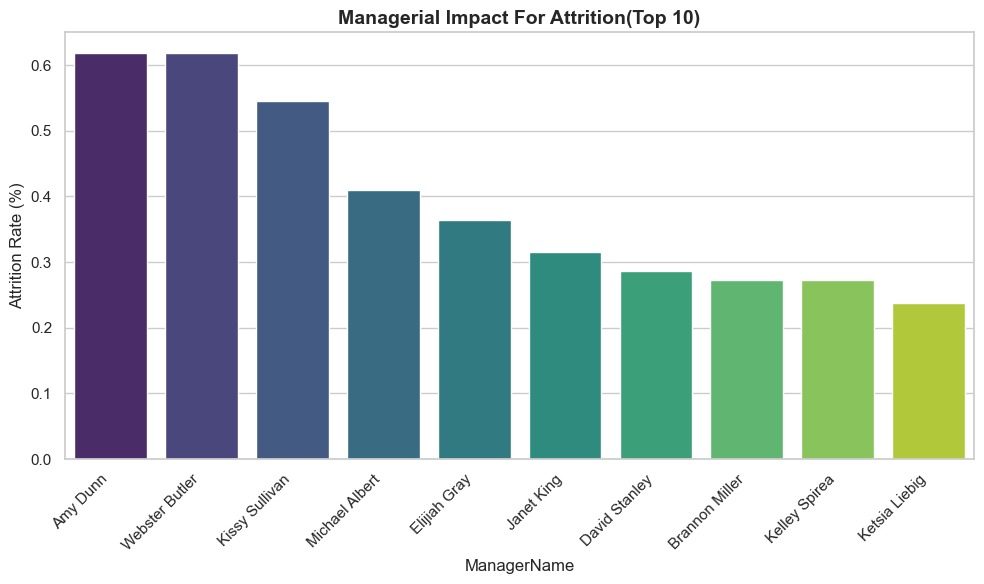

In [21]:
plt.figure(figsize=(10, 6))

# Filter top 10 managers to prevent x-axis clutter
top_managers = df['ManagerName'].value_counts().nlargest(10).index
df_top = df[df['ManagerName'].isin(top_managers)]

# Calculate Attrition Rate (Mean of binary Termd)
attrition_rates = df_top.groupby('ManagerName')['Termd'].mean().reset_index()
attrition_rates = attrition_rates.sort_values(by='Termd', ascending=False)
attrition_rates['ManagerName'] = attrition_rates['ManagerName'].astype(str)

sns.barplot(data=attrition_rates, x='ManagerName', y='Termd', palette='viridis')

plt.title('Managerial Impact For Attrition(Top 10)', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('ManagerName')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

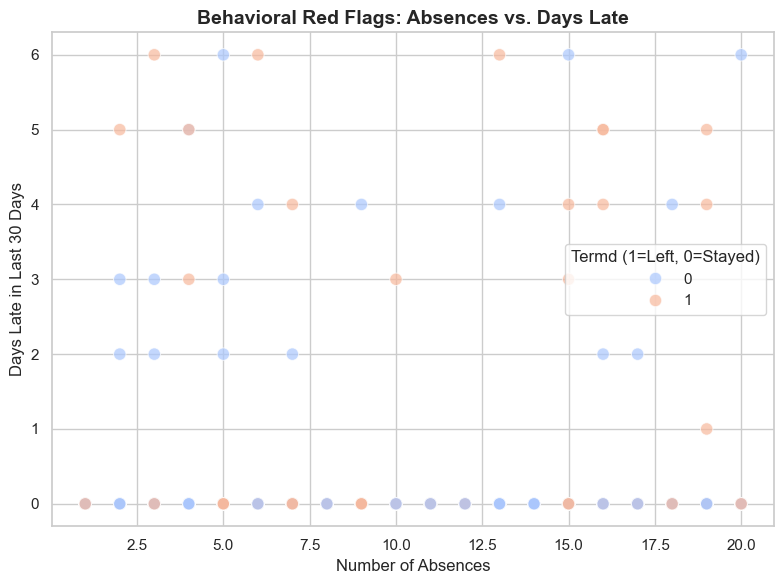

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='Absences', y='DaysLateLast30', hue='Termd', 
                palette='coolwarm', alpha=0.7, s=80)

plt.title('Behavioral Red Flags: Absences vs. Days Late', fontsize=14, fontweight='bold')
plt.legend(title='Termd (1=Left, 0=Stayed)')
plt.xlabel('Number of Absences')
plt.ylabel('Days Late in Last 30 Days')

plt.tight_layout()
plt.show()

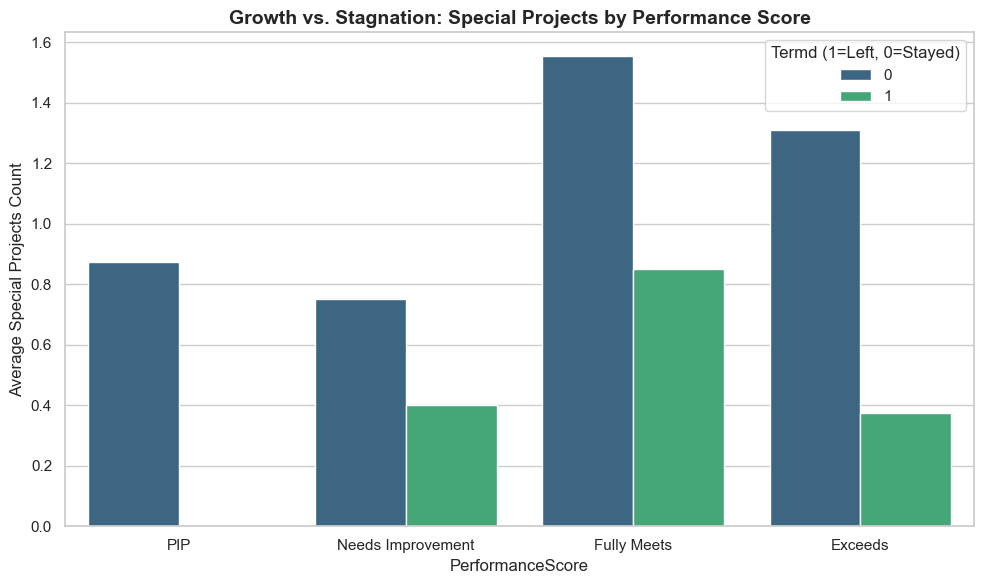

In [15]:
plt.figure(figsize=(10, 6))

# Define explicit order if PerformanceScore is categorical
perf_order = ['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']

sns.barplot(data=df, x='PerformanceScore', y='SpecialProjectsCount', hue='Termd', 
            palette='viridis', order=perf_order, errorbar=None)

plt.title('Growth vs. Stagnation: Special Projects by Performance Score', fontsize=14, fontweight='bold')
plt.ylabel('Average Special Projects Count')
plt.legend(title='Termd (1=Left, 0=Stayed)')

plt.tight_layout()
plt.show()

# Model Training

### Logistic Regression

=== LOGISTIC REGRESSION: BASELINE EVALUATION ===

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        40
           1       0.73      0.76      0.74        21

    accuracy                           0.82        61
   macro avg       0.80      0.81      0.80        61
weighted avg       0.82      0.82      0.82        61



C:\Users\user'\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


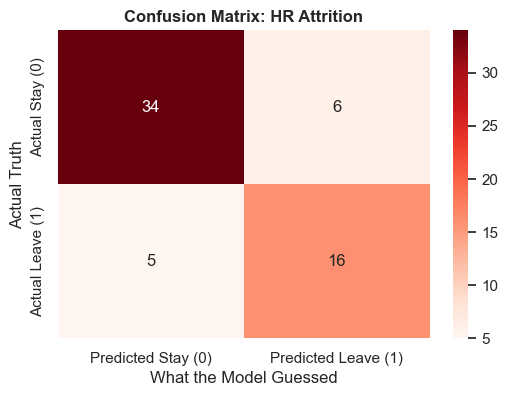

In [16]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. THE INCOMING DATA
# (Assuming 'df' already has your engineered 'Age_At_Review' and 'Tenure')
incoming_features = [
    'Salary', 'Termd', 'Position', 'Sex', 'MaritalDesc', 'DateofHire',       
    'DateofTermination', 'EmploymentStatus', 'Department', 'ManagerName',       
    'ManagerID', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',       
    'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'Age_At_Review', 'Tenure'
]

# Create a working copy with only these columns
model_df = df[incoming_features].copy()

# 2. THE SENIOR DS PRUNING (Removing Leakage & Noise)
leaky_and_noise_cols = ['DateofHire', 'DateofTermination', 'EmploymentStatus', 'ManagerName']
model_df = model_df.drop(columns=leaky_and_noise_cols)

# Drop any rows that still have NaNs in our core features to prevent math errors
model_df = model_df.dropna()

# 3. SPLIT TARGET AND FEATURES
y = model_df['Termd']
X = model_df.drop(columns=['Termd'])

# Ensure ManagerID is treated as a category (text), not a number
X['ManagerID'] = X['ManagerID'].astype(str)

# 4. ORGANIZE FEATURES FOR THE PIPELINE
numeric_features = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 
                    'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 
                    'Age_At_Review', 'Tenure']

nominal_features = ['Position', 'Sex', 'MaritalDesc', 'Department', 'ManagerID']

ordinal_features = ['PerformanceScore']
# Define the strict hierarchy for performance
perf_order = [['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']]

# 5. BUILD THE PREPROCESSOR (The "Translator")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_features),
        ('cat_ord', OrdinalEncoder(categories=perf_order), ordinal_features)
    ])

# 6. TRAIN / TEST SPLIT
# stratify=y ensures the percentage of people who quit is balanced in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. ASSEMBLE AND TRAIN THE MODEL
# class_weight='balanced' forces the model to care deeply about the people who leave!
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

# Let the model learn!
lr_model.fit(X_train, y_train)

# 8. EVALUATION
y_pred_lr = lr_model.predict(X_test)

print("=== LOGISTIC REGRESSION: BASELINE EVALUATION ===\n")
print(classification_report(y_test, y_pred_lr))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Stay (0)', 'Predicted Leave (1)'], 
            yticklabels=['Actual Stay (0)', 'Actual Leave (1)'])
plt.title('Confusion Matrix: HR Attrition', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('What the Model Guessed')
plt.show()

## Random Forest Classifier

C:\Users\user'\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\user'\AppData\Local\Temp\ipykernel_14772\3040713210.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=axes[1])


=== RANDOM FOREST: EVALUATION ===

              precision    recall  f1-score   support

           0       0.88      0.95      0.92        40
           1       0.89      0.76      0.82        21

    accuracy                           0.89        61
   macro avg       0.89      0.86      0.87        61
weighted avg       0.89      0.89      0.88        61



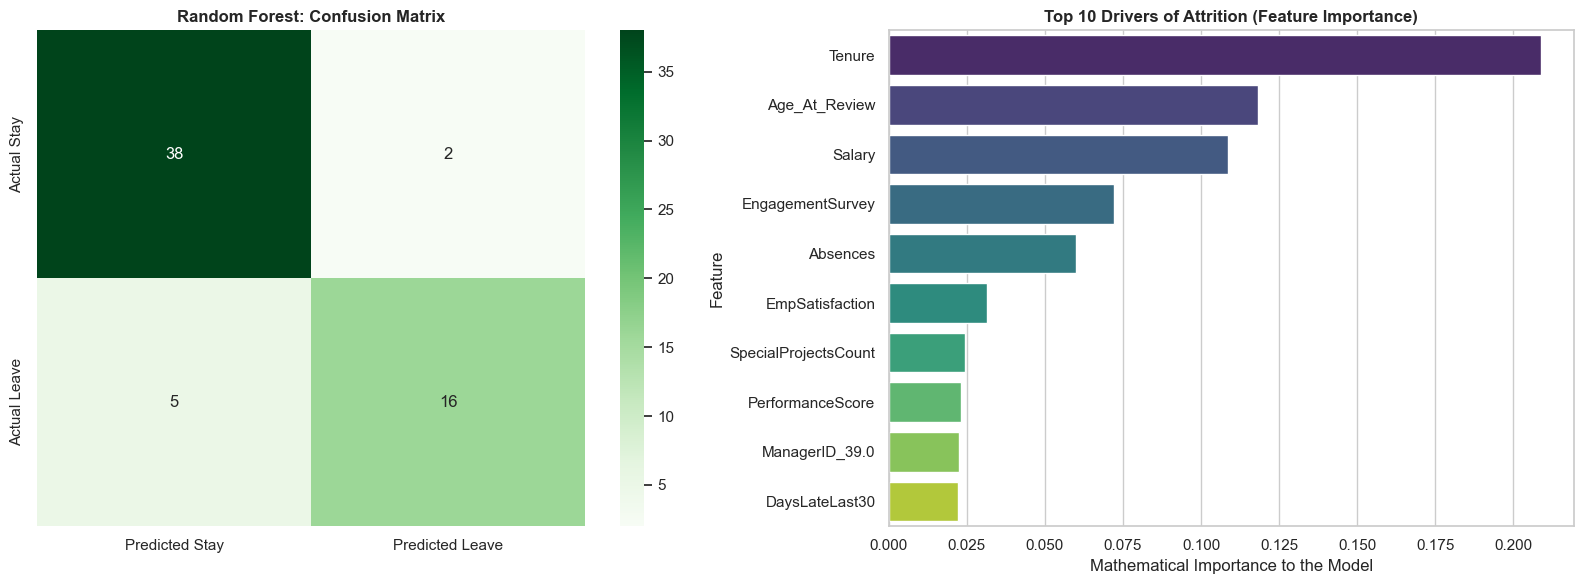

In [17]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

# 1. SETUP INCOMING DATA (Same as before)
incoming_features = [
    'Salary', 'Termd', 'Position', 'Sex', 'MaritalDesc', 
    'Department', 'ManagerID', 'PerformanceScore', 
    'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 
    'DaysLateLast30', 'Absences', 'Age_At_Review', 'Tenure'
]

model_df = df[incoming_features].dropna().copy()

y = model_df['Termd']
X = model_df.drop(columns=['Termd'])
X['ManagerID'] = X['ManagerID'].astype(str)

# 2. ORGANIZE FEATURES FOR PREPROCESSING
numeric_features = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 
                    'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 
                    'Age_At_Review', 'Tenure']
nominal_features = ['Position', 'Sex', 'MaritalDesc', 'Department', 'ManagerID']
ordinal_features = ['PerformanceScore']
perf_order = [['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']]

# 3. BUILD THE PREPROCESSOR
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), nominal_features),
        ('cat_ord', OrdinalEncoder(categories=perf_order), ordinal_features)
    ])

# 4. SPLIT THE DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. ASSEMBLE THE RANDOM FOREST PIPELINE
# n_estimators=100 means we are building 100 decision trees
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# 6. TRAIN THE MODEL
rf_model.fit(X_train, y_train)

# 7. EVALUATION
y_pred_rf = rf_model.predict(X_test)

print("=== RANDOM FOREST: EVALUATION ===\n")
print(classification_report(y_test, y_pred_rf))

# 8. VISUALIZE THE RESULTS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Stay', 'Predicted Leave'], 
            yticklabels=['Actual Stay', 'Actual Leave'], ax=axes[0])
axes[0].set_title('Random Forest: Confusion Matrix', fontweight='bold')

# B. Feature Importance Extraction
# Extract the names of the features after they were processed
feature_names = preprocessor.get_feature_names_out()
# Extract how much the model cared about each feature
importances = rf_model.named_steps['classifier'].feature_importances_

# Create a dataframe for plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

# Clean up names for the chart (optional, makes it look nicer)
importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '').str.replace('cat_nom__', '').str.replace('cat_ord__', '')

sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=axes[1])
axes[1].set_title('Top 10 Drivers of Attrition (Feature Importance)', fontweight='bold')
axes[1].set_xlabel('Mathematical Importance to the Model')

plt.tight_layout()
plt.show()

## Model Comparison

In [18]:
lr_accuracy= accuracy_score(y_test, y_pred_lr)
rf_accuracy= accuracy_score(y_test, y_pred_rf)
print(f"Logistic Regression Accuracy: {lr_accuracy:.2f}")
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

print("\n=== MODEL COMPARISON ===")

if lr_accuracy > rf_accuracy:
    print("Logistic Regression performed better.")
else:
    print("Random Forest performed better.")

Logistic Regression Accuracy: 0.82
Random Forest Accuracy: 0.89

=== MODEL COMPARISON ===
Random Forest performed better.
